# **CSCI 161.03 - Introduction to Social Computing**

**Author:** BINWAG, Louis III G. (`github/louis-uwie`)

# **I. Introduction**

As part of the major requirement for **CSCI 161.03 - Introduction to Social Computing**, the author,

In `r/Philippines`, users tend to interact about on-going controversial issues in the Philippines. This ranges from the most recent `Nepo Babies` to rather old but still very relevant and recurring, `Agricultural Prices`.

**What I want to find out are:**

1. What are the common underlying themes in topics concerning **Agriculture?**
2. What **dominant emotions** emerge in these online conversations?
3. What are common indications?

# **II. About the Dataset**

 Please note that there is a great chance of including other social media platforms as well due to rate-limits of Reddit API Scraping.

Currently, there is `248 Rows`, and `8 Columns`.


| Column           | Definition                                      | Sample                                                              |
| ---------------- | ----------------------------------------------- | ------------------------------------------------------------------- |
| `post_title`     | Title of the Reddit post                        | *"Why is Python so popular in data science?"*                       |
| `post_url`       | Direct link to the Reddit post                  | `https://www.reddit.com/r/datascience/comments/abc123/...`          |
| `post_body`      | Main body text of the Reddit post (if provided) | *"I’ve noticed a lot of job postings require Python experience..."* |
| `post_author`    | Username of the Reddit post’s author            | `u/data_guru`                                                       |
| `post_score`     | Upvotes minus downvotes for the post            | `1542`                                                              |
| `comment`        | Text of the Reddit comment                      | *"Python has great libraries like pandas and scikit-learn."*        |
| `comment_author` | Username of the Reddit comment’s author         | `u/ml_enthusiast`                                                   |
| `comment_score`  | Upvotes minus downvotes for the comment         | `237`                                                               |



# **III. Data Collection**

Data collection will primarily utilize Reddit's PRAW (API) for datascraping. Connecting to Google drive for ease of use since the author will be using google collab for a more streamline and 'smoother' project.


In [1]:
%pip install praw numpy nltk pandas

  Using cached praw-7.8.1-py3-none-any.whl.metadata (9.4 kB)
  Using cached prawcore-2.4.0-py3-none-any.whl.metadata (5.0 kB)
  Using cached update_checker-0.18.0-py3-none-any.whl.metadata (2.3 kB)
Using cached praw-7.8.1-py3-none-any.whl (189 kB)
Using cached prawcore-2.4.0-py3-none-any.whl (17 kB)
Using cached update_checker-0.18.0-py3-none-any.whl (7.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [praw]2/3 [praw]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# from dotenv import load_dotenv
# import os

# load_dotenv("/content/drive/CSCI 161/Project/redditdatascrape.env", override=True)

# CLIENT_ID = os.getenv("CLIENT_ID")
# CLIENT_SECRET = os.getenv("CLIENT_SECRET")

# print("CLIENT_ID:", CLIENT_ID)
# print("CLIENT_SECRET:", CLIENT_SECRET)


In [3]:
import pandas as pd
import numpy as np
import praw
import pandas as pd
import os

In [ ]:
reddit = praw.Reddit(
    client_id="******",
    client_secret="******",
    user_agent="script:reddit_scraper:v1.0"
)

print("Read-only mode:", reddit.read_only)

Read-only mode: True


In [5]:
subreddit = reddit.subreddit("Philippines")

posts_data = []

# Fetch more posts (adjust as needed)
for post in subreddit.search("Agriculture", limit=500):
    body = post.selftext if post.selftext else "[No text - maybe image/link post]"

    posts_data.append({
        "post_title": post.title,
        "post_url": "https://reddit.com" + post.permalink,
        "comment": None,
        "comment_author": None,
        "comment_score": None,
        "post_body": body,
        "post_score": post.score,
        "post_author": post.author.name if post.author else "[deleted]",
        "created_utc": pd.to_datetime(post.created_utc, unit="s")
    })

    # Fetch comments
    post.comments.replace_more(limit=0)
    for comment in post.comments.list():
        posts_data.append({
            "post_title": post.title,
            "post_url": "https://reddit.com" + post.permalink,
            "comment": comment.body,
            "comment_author": comment.author.name if comment.author else "[deleted]",
            "comment_score": comment.score,
            "post_body": None,
            "post_score": None,
            "post_author": None,
            "created_utc": pd.to_datetime(comment.created_utc, unit="s")
        })

# Save locally
df = pd.DataFrame(posts_data)

output_dir = "/Users/uwie/Documents/_Github/CSCI161-SocialComputing/Binwag - PhilippineRedditAgricultureAnalysis/data"
os.makedirs(output_dir, exist_ok=True) 

output_path = os.path.join(output_dir, "reddit_data.csv")
df.to_csv(output_path, index=False)


In [6]:
reddit_collected = pd.read_csv(
    "/Users/uwie/Documents/_Github/CSCI161-SocialComputing/Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_data.csv"
)
reddit_collected.tail()


,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc
13762,"121 years ago on July 2, 1899, the Manila Agri...",https://reddit.com/r/Philippines/comments/hjkb...,Nice. I see what you did there.,PhilippineLeadX,3.0,NaN,NaN,NaN,2020-07-02 11:34:00
13763,World Soil Day: How the SoilMate App is Tackli...,https://reddit.com/r/Philippines/comments/k9jf...,NaN,NaN,NaN,[No text - maybe image/link post],2.0,cottage_ogre,2020-12-09 02:57:18
13764,Benguet State University - BS Agriculture Feed...,https://reddit.com/r/Philippines/comments/gc5m...,NaN,NaN,NaN,Hello guys!\n\nI'm currently 29 years old and ...,3.0,agriwannabe,2020-05-02 12:26:35
13765,Benguet State University - BS Agriculture Feed...,https://reddit.com/r/Philippines/comments/gc5m...,Dude can i join you?,readytraderone,1.0,NaN,NaN,NaN,2020-05-02 16:29:37
13766,Benguet State University - BS Agriculture Feed...,https://reddit.com/r/Philippines/comments/gc5m...,Maganda naman. Hindi malaki ang bayarin.,fmp321,1.0,NaN,NaN,NaN,2020-05-02 16:58:55


---
**Rappler - News Article**

In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# ========================================
# CONFIGURATION
# ========================================

BASE_TOPIC_URL = "https://www.rappler.com/topic/agriculture/page/{}/"
START_PAGE = 1
END_PAGE = 5  # adjust after confirming how many pages exist
OUTPUT_FILE = "rappler_agriculture.csv"

# Initialize DataFrame
corpus = pd.DataFrame(columns=['title', 'link', 'date_published', 'author', 'text'])


# ========================================
# SCRAPER FUNCTIONS
# ========================================

def get_article_details(article_url):
    """Extract title, date, author, and text from an article."""
    try:
        res = requests.get(article_url, timeout=10)
        res.raise_for_status()
        soup = BeautifulSoup(res.text, "html.parser")

        # Title
        title_tag = soup.find("h1")
        title = title_tag.get_text(strip=True) if title_tag else None

        # Date
        date_tag = soup.find("time")
        date_published = date_tag.get("datetime") if date_tag else None

        # Author
        author_tag = soup.find("a", rel="author") or soup.find("span", class_="author__name")
        author = author_tag.get_text(strip=True) if author_tag else None

        # Article text
        paragraphs = soup.select("article p")
        text = " ".join(p.get_text(strip=True) for p in paragraphs) if paragraphs else None

        return [title, article_url, date_published, author, text]

    except Exception as e:
        print(f"Error scraping article {article_url}: {e}")
        return [None, article_url, None, None, None]


def scrape_topic_page(page_number):
    """Scrapes one page of the Agriculture topic."""
    url = BASE_TOPIC_URL.format(page_number)
    print(f"Scraping topic page {page_number}: {url}")

    try:
        res = requests.get(url, timeout=10)
        res.raise_for_status()
        soup = BeautifulSoup(res.text, "html.parser")
    except Exception as e:
        print(f"Failed to load topic page {page_number}: {e}")
        return []

    articles_data = []

    # On archive pages, each article link is inside <h2><a href=...>
    article_links = [a['href'] for a in soup.select("h2 > a[href]")]
    if not article_links:
        print(f"No articles found on page {page_number}.")
        return []

    for link in article_links:
        if not link.startswith("http"):
            link = "https://www.rappler.com" + link

        article_details = get_article_details(link)
        articles_data.append(article_details)
        print(f"Scraped: {article_details[0]}")
        time.sleep(1)  # polite delay

    return articles_data


# ========================================
# MAIN LOOP
# ========================================

all_data = []

for page in range(START_PAGE, END_PAGE + 1):
    page_data = scrape_topic_page(page)
    if not page_data:
        print(f"Stopping at page {page} (no more articles).")
        break
    all_data.extend(page_data)

# Combine into DataFrame
corpus = pd.DataFrame(all_data, columns=['title', 'link', 'date_published', 'author', 'text'])

# Save to CSV
corpus.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
print(f"Scraping complete. {len(corpus)} articles saved to {OUTPUT_FILE}.")


Scraping topic page 1: https://www.rappler.com/topic/agriculture/page/1/
Scraped: Apl.de.Ap extends his impact from stage to soil
Scraped: What is Japan’s Matsusaka beef, and why is it so rare?
Scraped: Arms to farms: Maguindanao del Sur’s agriculture roadmap for former rebels
Scraped: Chinese smugglers ‘operate freely’ with help of PH gov’t officials — Pangilinan
Scraped: Bounty Fresh aims to strengthen operations amid growing appetite for poultry
Scraped: Century Pacific buys another coconut facility. What’s next for its food business?
Scraped: [Ask the Tax Whiz] How do Filipinos benefit from a higher excise tax on sugary drinks?
Scraped: DA to take over farm-to-market road projects from DPWH
Scraped: Zaldy Co-linked firm ranks No. 3 in 2024 farm-to-market road projects
Scraping topic page 2: https://www.rappler.com/topic/agriculture/page/2/
Scraped: Trump’s tariff war is ASEAN ministers’ lunchtime talk: ‘Have you closed?’
Scraped: Cheng family, owner of Bounty Fresh, now has 200 res

# **Data Preprocessing**

In [8]:
# conda activate "F:\_GitHub\CSCI161-SocialComputing\Binwag - PhilippineRedditAgricultureAnalysis\env"
# OR go into the directory above, and conda activate
# conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia

# conda activate ./env
# jupyter notebook


In [9]:
import os
import sys
import subprocess

print("Checking GPU and environment...")

conda_env = os.environ.get("CONDA_PREFIX", None)
print(f"Conda environment: {conda_env if conda_env else 'Not in Conda'}")

try:
    result = subprocess.run(["nvidia-smi"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode == 0:
        print("NVIDIA GPU detected.")
        print(result.stdout.split("\n")[2]) 
    else:
        print("No NVIDIA GPU found or drivers missing.")
except FileNotFoundError:
    print("'nvidia-smi' not found — NVIDIA drivers may not be installed.")

try:
    import torch
    print("PyTorch already installed.")
except ImportError:
    print("Installing PyTorch with CUDA 12.1 support...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "torch", "torchvision", "torchaudio",
        "--extra-index-url", "https://download.pytorch.org/whl/cu121"
    ])
    import torch

try:
    import torch
    print("PyTorch CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("Using GPU:", torch.cuda.get_device_name(0))
    else:
        print("CUDA not available — running on CPU.")
except Exception as e:
    print("PyTorch check failed:", e)
    print("Trying TensorFlow GPU check instead...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow[and-cuda]"])
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    print("TensorFlow GPUs detected:" if gpus else "TensorFlow found no GPU.", gpus)

print("Setup complete.")


Checking GPU and environment...
Conda environment: Not in Conda
'nvidia-smi' not found — NVIDIA drivers may not be installed.
Installing PyTorch with CUDA 12.1 support...
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for torch


CalledProcessError: Command '['/Users/uwie/Documents/_Github/CSCI161-SocialComputing/.venv/bin/python', '-m', 'pip', 'install', 'torch', 'torchvision', 'torchaudio', '--extra-index-url', 'https://download.pytorch.org/whl/cu121']' returned non-zero exit status 1.

In [ ]:
import pandas as pd
import os

print(f"Current directory: {os.getcwd()}")

reddit_raw = pd.read_csv(r"data/Reddit/reddit_data.csv")
rappler_raw = pd.read_csv(r"data/News/rappler_agriculture.csv")

reddit_raw.info()
reddit_raw.tail()



In [ ]:
rappler_raw.info()
rappler_raw.tail()

---
**Cleaning Reddit Data**

In [ ]:
import pandas as pd
import re

reddit_clean = reddit_raw.drop(columns=['comment_author', 'post_author','post_score','comment_score'])

reddit_clean = reddit_clean.dropna(subset=['post_title', 'comment'], how='all')

# Combine title + body into one field (if body exists)
reddit_clean['post_full'] = reddit_clean.apply(
    lambda row: f"{row['post_title']} {row['post_body']}" if pd.notnull(row['post_body']) else row['post_title'],
    axis=1
)

# Text normalization
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"<.*?>", "", text)                # remove HTML tags
    text = re.sub(r"[\r\n]+", " ", text)             # newlines → space
    text = re.sub(r"\s+", " ", text).strip()         # normalize whitespace
    text = text.lower()                              # lowercase
    text = text.replace("[deleted]", "").replace("[removed]", "")
    return text.strip()

reddit_clean['post_full'] = reddit_clean['post_full'].apply(clean_text)
reddit_clean['comment'] = reddit_clean['comment'].apply(clean_text)

reddit_clean = reddit_clean[(reddit_clean['post_full'].str.len() > 0) | (reddit_clean['comment'].str.len() > 0)]

reddit_clean = reddit_clean.drop_duplicates(subset=['post_url', 'comment'])

reddit_clean = reddit_clean.reset_index(drop=True)

reddit_clean.to_csv("data/Reddit/reddit_clean.csv", index=False, encoding='utf-8-sig')

print(f"Cleaned {len(reddit_clean)} rows saved to reddit_clean.csv")
reddit_clean.tail(3)


Reddit is cleaned by normalizing text, duplicates, and removing unnused columns for this study.

In [ ]:
rappler_clean = rappler_raw.copy()

# Drop the 'author' column
rappler_clean = rappler_clean.drop(columns=['author'])

# Text normalization function
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"<.*?>", "", text)                # remove HTML tags
    text = re.sub(r"[\r\n]+", " ", text)            # newlines → space
    text = re.sub(r"\s+", " ", text).strip()        # normalize whitespace
    text = text.lower()                              # lowercase
    text = text.replace("[deleted]", "").replace("[removed]", "")
    return text.strip()

rappler_clean['cleaned_text'] = rappler_clean['text'].apply(clean_text)
rappler_clean.to_csv(r"data/News/rappler_clean.csv", index=False)

rappler_clean.tail()

---

Final overview

In [ ]:
rappler_clean.info()
rappler_clean.isna().sum()


In [ ]:
rappler_clean[['text', 'cleaned_text']].tail()


# **EDA**

`reddit_clean` and `rappler_clean` will be used.

---
**Basic dataset overview**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud
from wordcloud import STOPWORDS

reddit_clean = pd.read_csv(r"../data/Reddit/reddit_clean.csv")
rappler_clean = pd.read_csv(r"../data/News/rappler_clean.csv")

reddit_clean.info()
rappler_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12730 entries, 0 to 12729
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   post_title   12730 non-null  object
 1   post_url     12730 non-null  object
 2   comment      12503 non-null  object
 3   post_body    227 non-null    object
 4   created_utc  12730 non-null  object
 5   post_full    12730 non-null  object
dtypes: object(6)
memory usage: 596.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           121 non-null    object
 1   link            121 non-null    object
 2   date_published  121 non-null    object
 3   text            121 non-null    object
 4   cleaned_text    121 non-null    object
dtypes: object(5)
memory usage: 4.9+ KB


In [ ]:
# Stopwrods

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
english_stop = stopwords.words("english")

filipino_stopwords = [
    "sa","ang","ng","mga","si","ni","kay","kina",
    "ito","iyan","iyon","doon","diyan","dito",
    "ko","mo","nya","niya","natin","namin","nyo","ninyo",
    "sila","kami","tayo","kayo",
    "ay","may","wala","meron","naman","rin","din",
    "pa","ba","po","ho","eh","yung","yup","nope",
    "kung","kapag","pero","kasi","para","habang","bago",
    "nga","lang","daw","raw","yata","pala","talaga",
    "siguro","naka","ni","siya",
    
    # noise words
    "haha","hahaha","hehe","lol","omg","hmmmm","hmmmmmm",
    "tsk","hay","amp","grabe",
    
    # more noise as the code is ran
    "lalala", "brgy", "sen", "ph", "phl", "gov",
    "committee", "chairmanships", "said", "s",
]

combined_stopwords = list(set(english_stop + filipino_stopwords))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Uwie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
**Word Cloud based on Word Frequency**

In [ ]:
def generate_wordcloud(text_series, title, extra_stopwords=None):
    all_text = ' '.join(text_series)
    
    stopwords = set(STOPWORDS)
    if extra_stopwords:
        stopwords.update(extra_stopwords).union(combined_stopwords)
    
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(all_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# --- Function to compute text stats ---
def add_text_stats(df, column):
    df['text_length'] = df[column].apply(len)
    df['word_count'] = df[column].apply(lambda x: len(x.split()))
    return df

# --- Function to plot Seaborn visualizations ---
def plot_text_stats(df, dataset_name):
    plt.figure(figsize=(12,5))
    
    # Text length histogram
    plt.subplot(1,2,1)
    sns.histplot(df['text_length'], bins=30, kde=True, color='skyblue')
    plt.title(f'{dataset_name} Text Length Distribution')
    plt.xlabel('Characters')
    
    # Word count histogram
    plt.subplot(1,2,2)
    sns.histplot(df['word_count'], bins=30, kde=True, color='salmon')
    plt.title(f'{dataset_name} Word Count Distribution')
    plt.xlabel('Words')
    
    plt.tight_layout()
    plt.show()
    

Reddit Text Stats Summary:
        text_length   word_count
count  12730.000000  12730.00000
mean      99.799921     15.90055
std      126.707288     20.28687
min        4.000000      1.00000
25%       55.000000      9.00000
50%       72.000000     12.00000
75%      114.000000     20.00000
max     6082.000000   1006.00000


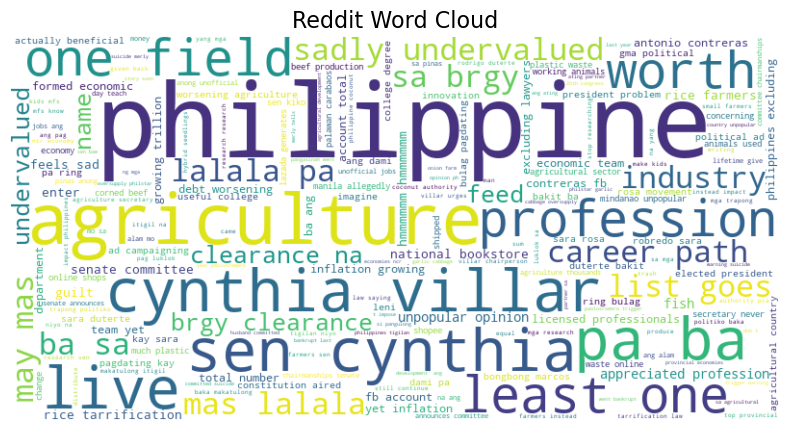

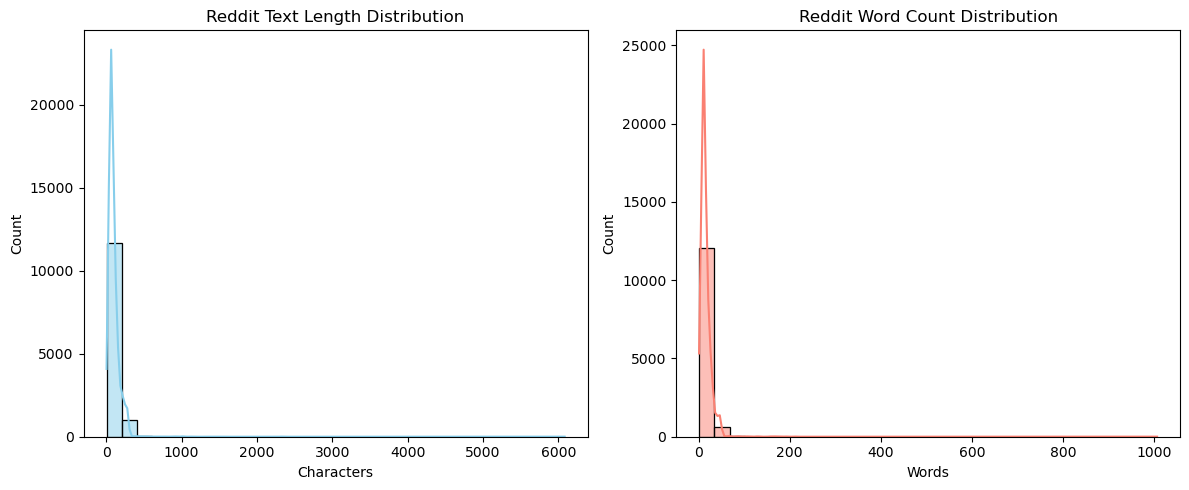

In [ ]:
reddit_clean = add_text_stats(reddit_clean, "post_full")
print("Reddit Text Stats Summary:")
print(reddit_clean[['text_length', 'word_count']].describe())
generate_wordcloud(reddit_clean['post_full'], "Reddit Word Cloud")
plot_text_stats(reddit_clean, "Reddit")

Rappler Text Stats Summary:
        text_length   word_count
count    121.000000   121.000000
mean    3791.082645   595.752066
std     2110.447329   334.902630
min      437.000000    67.000000
25%     2191.000000   341.000000
50%     3295.000000   509.000000
75%     4873.000000   738.000000
max    10015.000000  1647.000000


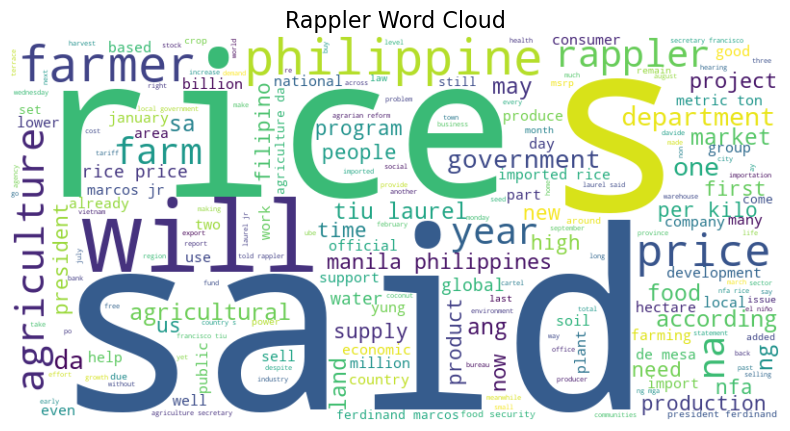

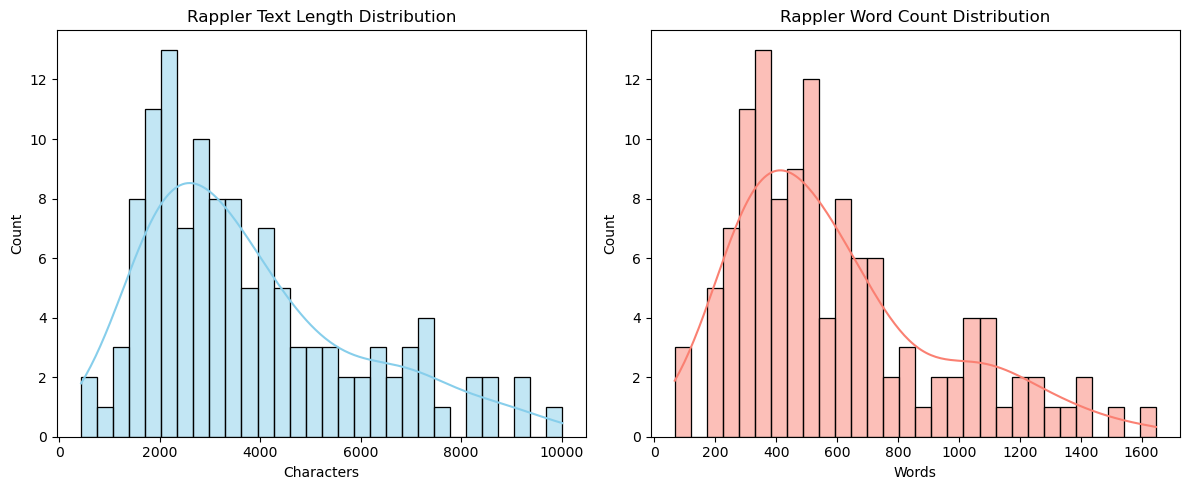

In [ ]:
rappler_clean = add_text_stats(rappler_clean, "cleaned_text")
print("Rappler Text Stats Summary:")
print(rappler_clean[['text_length', 'word_count']].describe())
generate_wordcloud(rappler_clean['cleaned_text'], "Rappler Word Cloud")
plot_text_stats(rappler_clean, "Rappler")


---
**Getting top words**

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def get_top_words(text_series, n=20, extra_stopwords=None):
    """
    Returns top n frequent words (excluding stopwords)
    """
    all_text = ' '.join(text_series).lower().split()
    stop_words_set = set(stopwords.words('english'))
    if extra_stopwords:
        stop_words_set.update(extra_stopwords)
    
    filtered_words = [w for w in all_text if w.isalpha() and w not in stop_words_set]
    word_freq = Counter(filtered_words)
    return word_freq.most_common(n)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Uwie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
reddit_top_words = get_top_words(reddit_clean['post_full'], n=20)
print("Reddit Top 20 Words:")
print(reddit_top_words)

rappler_top_words = get_top_words(rappler_clean['cleaned_text'], n=20)
print("Rappler Top 20 Words:")
print(rappler_top_words)


Reddit Top 20 Words:
[('agriculture', 2568), ('sa', 2002), ('na', 1554), ('ang', 1302), ('ng', 1264), ('rice', 1118), ('agricultural', 1112), ('philippines', 1005), ('profession', 918), ('pa', 829), ('ba', 782), ('department', 636), ('may', 634), ('cynthia', 632), ('committee', 601), ('senate', 597), ('mga', 593), ('one', 591), ('marcos', 581), ('farmers', 565)]
Rappler Top 20 Words:
[('rice', 478), ('said', 405), ('ng', 223), ('agriculture', 215), ('food', 205), ('farmers', 186), ('philippines', 183), ('sa', 182), ('also', 181), ('na', 163), ('prices', 142), ('government', 138), ('agricultural', 138), ('price', 138), ('department', 132), ('ang', 129), ('would', 123), ('da', 120), ('marcos', 117), ('per', 117)]


In [ ]:
# Define Filipino stopwords
filipino_stopwords = {'na', 'sa', 'ang', 'mga', 'pa', 'ba', 'ng', 'ay', 'si', 'ni', 'kay', 'may', 'also', 'mas'}

# Get top words excluding English + Filipino stopwords
reddit_top_words = get_top_words(
    reddit_clean['post_full'], 
    n=20, 
    extra_stopwords=filipino_stopwords
)
print("Reddit Top 20 Words (Filipino Stopwords Removed):")
print(reddit_top_words)

rappler_top_words = get_top_words(
    rappler_clean['cleaned_text'], 
    n=20, 
    extra_stopwords=filipino_stopwords
)
print("Rappler Top 20 Words (Filipino Stopwords Removed):")
print(rappler_top_words)



Reddit Top 20 Words (Filipino Stopwords Removed):
[('agriculture', 2568), ('rice', 1118), ('agricultural', 1112), ('philippines', 1005), ('profession', 918), ('department', 636), ('cynthia', 632), ('committee', 601), ('senate', 597), ('one', 591), ('marcos', 581), ('farmers', 565), ('goes', 563), ('clearance', 560), ('fish', 505), ('least', 496), ('bakit', 495), ('live', 480), ('list', 479), ('field', 479)]
Rappler Top 20 Words (Filipino Stopwords Removed):
[('rice', 478), ('said', 405), ('agriculture', 215), ('food', 205), ('farmers', 186), ('philippines', 183), ('prices', 142), ('government', 138), ('agricultural', 138), ('price', 138), ('department', 132), ('would', 123), ('da', 120), ('marcos', 117), ('per', 117), ('laurel', 116), ('local', 108), ('one', 102), ('according', 100), ('president', 100)]


---
Post frequency over time

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_posts_over_time(df, date_column, dataset_name):
    """
    Plots number of posts/articles per day using Seaborn
    """
    # Ensure datetime
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    
    # Count posts per day
    ts = df.groupby(df[date_column].dt.date).size().reset_index(name='count')
    ts.rename(columns={date_column: 'date'}, inplace=True)
    
    # Plot with Seaborn
    plt.figure(figsize=(14,5))
    sns.lineplot(data=ts, x='date', y='count', marker='o')
    plt.title(f'{dataset_name} Posts Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Posts', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


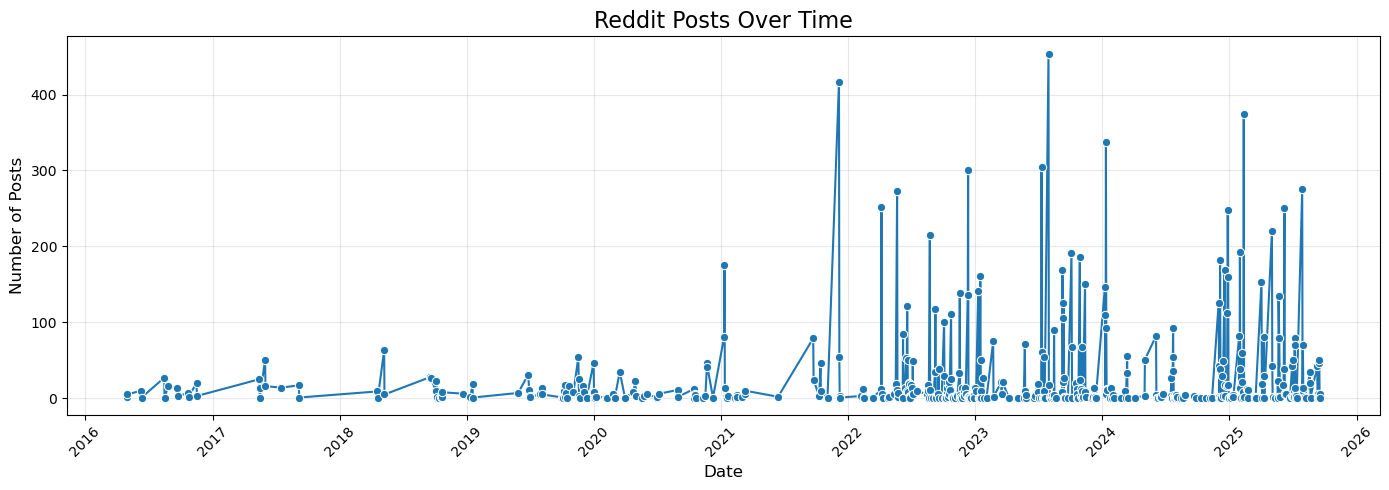

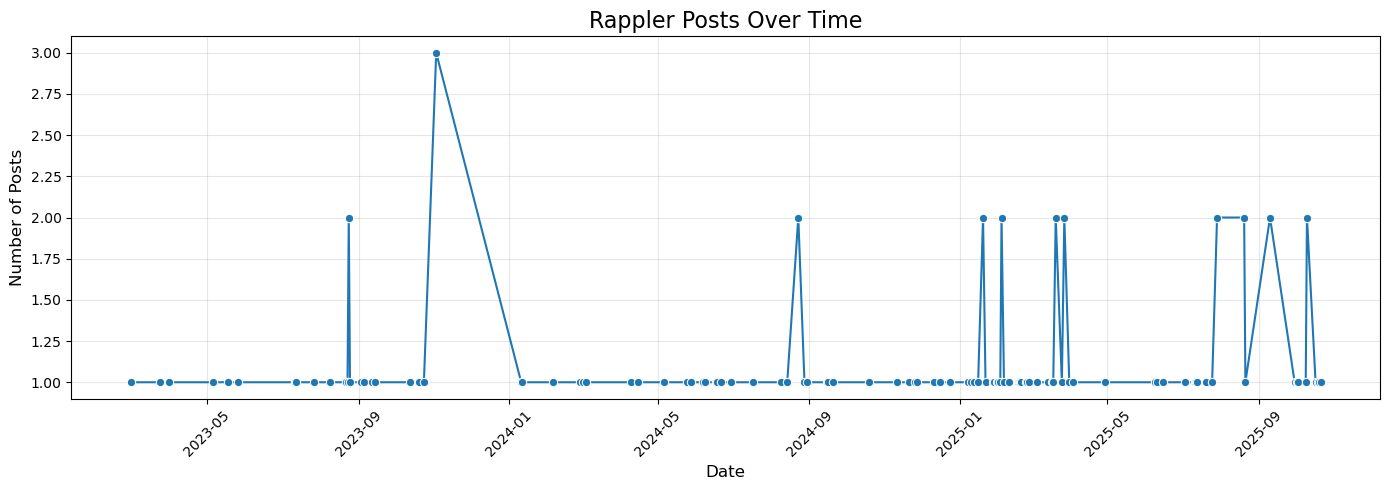

In [ ]:
plot_posts_over_time(reddit_clean, 'created_utc', 'Reddit')
plot_posts_over_time(rappler_clean, 'date_published', 'Rappler')


---
**Summary of EDA**

The EDA included:
1. Inspecting dataset structure using data.info().
2. Generating a basic (but still noisy) word cloud from raw word frequencies.
3. Identifying the top most frequent words.
4. Plotting post frequency over time to observe activity trends.

## **Word Embeddings**

In [ ]:
!pip install scikit-learn pandas numpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Load Reddit
reddit_corpus = pd.read_csv("../data/Reddit/reddit_clean.csv")
print(reddit_corpus.tail())

# Load Rappler
rappler_corpus = pd.read_csv("../data/News/rappler_clean.csv")
print(rappler_corpus.tail())


                                              post_title  \
12725  Philippines, Japan deepen ties with $1.5 billi...   
12726  Philippines, Japan deepen ties with $1.5 billi...   
12727  Philippines, Japan deepen ties with $1.5 billi...   
12728  Philippines, Japan deepen ties with $1.5 billi...   
12729  Philippines, Japan deepen ties with $1.5 billi...   

                                                post_url  \
12725  https://reddit.com/r/Philippines/comments/1cio...   
12726  https://reddit.com/r/Philippines/comments/1cio...   
12727  https://reddit.com/r/Philippines/comments/1cio...   
12728  https://reddit.com/r/Philippines/comments/1cio...   
12729  https://reddit.com/r/Philippines/comments/1cio...   

                                                 comment post_body  \
12725                       that’s why fuck the dutertes       NaN   
12726                                  fr? that's scary.       NaN   
12727                  this partnership is very daijoubu       NaN  

In [ ]:
reddit_texts = reddit_corpus["post_full"].astype(str).tolist()
rappler_texts = rappler_corpus["text"].astype(str).tolist()


In [ ]:
# Stopwrods

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
english_stop = stopwords.words("english")

filipino_stopwords = [
    "sa","ang","ng","mga","si","ni","kay","kina",
    "ito","iyan","iyon","doon","diyan","dito",
    "ko","mo","nya","niya","natin","namin","nyo","ninyo",
    "sila","kami","tayo","kayo",
    "ay","may","wala","meron","naman","rin","din",
    "pa","ba","po","ho","eh","yung","yup","nope",
    "kung","kapag","pero","kasi","para","habang","bago",
    "nga","lang","daw","raw","yata","pala","talaga",
    "siguro","naka","ni","siya",
    
    # noise words
    "haha","hahaha","hehe","lol","omg","hmmmm","hmmmmmm",
    "tsk","hay","amp","grabe",
    
    # more noise as the code is ran
    "lalala", "brgy", "sen", "ph", "phl", "gov",
    "committee", "chairmanships"
]

combined_stopwords = list(set(english_stop + filipino_stopwords))



[nltk_data] Downloading package stopwords to /Users/uwie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
**Reddit BoW**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Use only the combined post text (title + body)
texts_reddit = reddit_corpus["post_full"].astype(str)

vectorizer = CountVectorizer(
    stop_words=combined_stopwords,
    max_df=0.95,
    min_df=2,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'   # remove numbers, symbols, 1-letter tokens
)

reddit_bow = vectorizer.fit_transform(texts_reddit)
reddit_bow.shape


(12730, 1790)

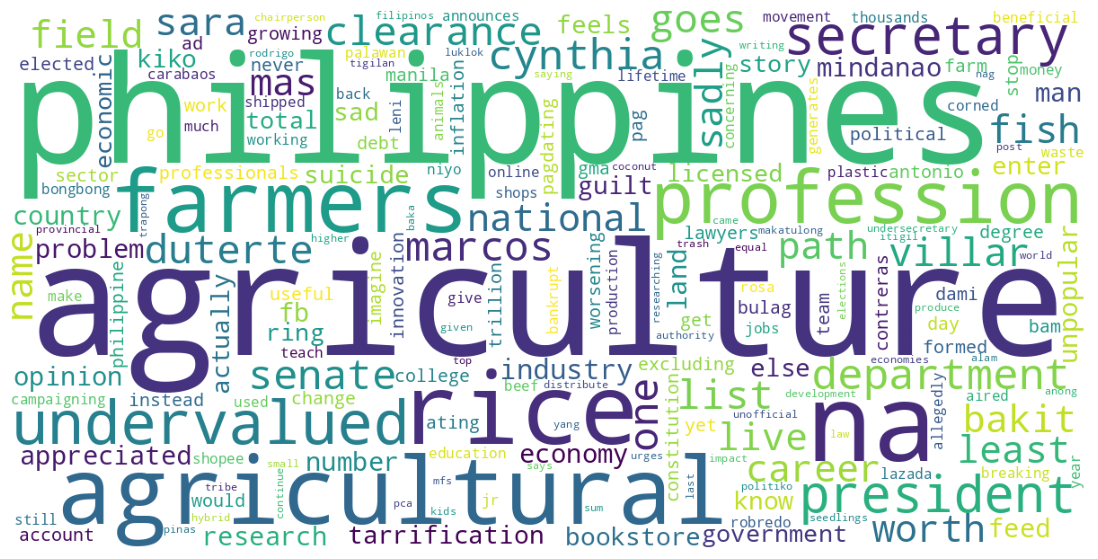

In [ ]:
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt

# Get vocabulary + term frequencies
vocab = vectorizer.get_feature_names_out()
word_freq = np.array(reddit_bow.sum(axis=0)).flatten()

freq_dict = dict(zip(vocab, word_freq))

# Generate the cleaned, BoW-based wordcloud
plt.figure(figsize=(15, 7))
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)
plt.imshow(wc.generate_from_frequencies(freq_dict))
plt.axis("off")
plt.show()


---
**Rappler BoW**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Use only the combined post text (title + body)
texts_reddit = rappler_corpus["cleaned_text"].astype(str)

vectorizer = CountVectorizer(
    stop_words=combined_stopwords,
    max_df=0.95,
    min_df=2,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'   # remove numbers, symbols, 1-letter tokens
)

rappler_bow = vectorizer.fit_transform(texts_reddit)
rappler_bow.shape


(121, 3878)

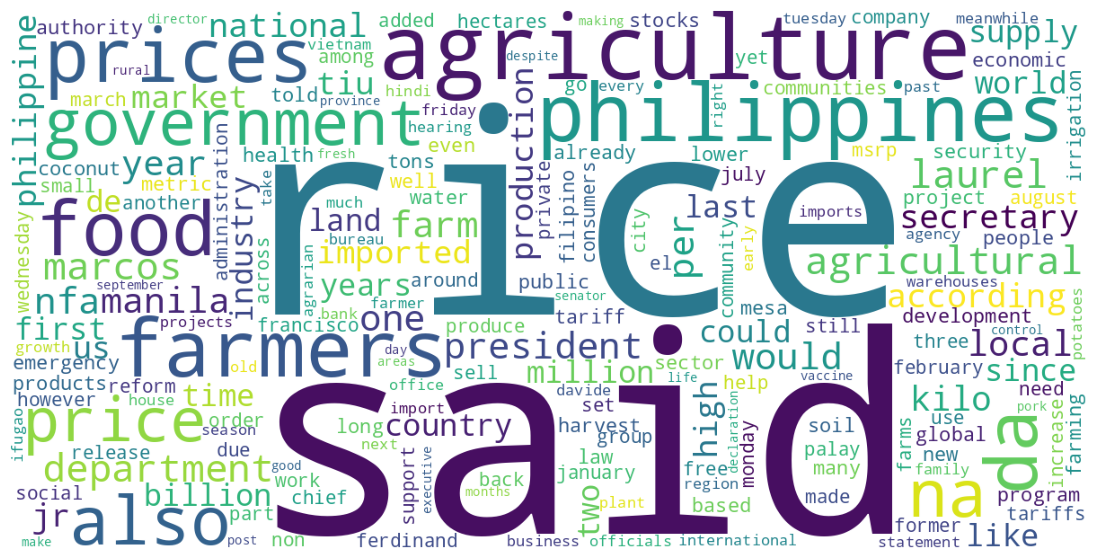

In [ ]:
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt

# Get vocabulary + term frequencies
vocab = vectorizer.get_feature_names_out()
word_freq = np.array(rappler_bow.sum(axis=0)).flatten()

freq_dict = dict(zip(vocab, word_freq))

# Generate the cleaned, BoW-based wordcloud
plt.figure(figsize=(15, 7))
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)
plt.imshow(wc.generate_from_frequencies(freq_dict))
plt.axis("off")
plt.show()


---
**LDA, Topic Modelling for Reddit**

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

reddit_lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)
reddit_lda_model.fit(reddit_bow)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [ ]:
def show_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"\nTopic {idx+1}:")
        print(" | ".join(top_words))

feature_names = vectorizer.get_feature_names_out()
show_topics(reddit_lda_model, feature_names)



Topic 1:
lot | africa | integrated | cases | importing | jayson | fever | announced | million | representative | affordable | de

Topic 2:
lot | africa | done | hectare | science | businesses | living | different | integrated | importations | financial | immediately

Topic 3:
heat | laurel | growing | lot | distributed | irrigation | million | representative | parents | energy | industriya | integrated

Topic 4:
lot | affordable | october | records | landed | millions | harvest | group | di | children | among | accessible

Topic 5:
africa | operates | determined | personal | association | play | quimbo | establish | promote | mesa | result | customs


In [ ]:
topic_distribution = reddit_lda_model.transform(reddit_bow)

reddit_corpus["dominant_topic"] = topic_distribution.argmax(axis=1)
reddit_corpus["topic_score"] = topic_distribution.max(axis=1)

reddit_corpus.to_csv("../data/Reddit/reddit_with_topics.csv", index=False)


---
**LDA, Topic Modelling for Rappler**

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

rappler_lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)

rappler_lda_model.fit(rappler_bow)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [ ]:
def show_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"\nTopic {idx+1}:")
        print(" | ".join(top_words))

feature_names = vectorizer.get_feature_names_out()
show_topics(rappler_lda_model, feature_names)



Topic 1:
farmers | farm | food | one | rice | like | also | farming | years | soil | people | agricultural

Topic 2:
price | rice | prices | also | marcos | president | agriculture | year | supply | august | government | economic

Topic 3:
na | agriculture | laurel | marcos | farmers | land | agricultural | sector | reform | president | agrarian | also

Topic 4:
rice | da | prices | nfa | kilo | food | per | imported | farmers | agriculture | price | government

Topic 5:
agriculture | government | would | also | project | according | farmers | irrigation | department | production | philippine | national


In [ ]:
topic_distribution = rappler_lda_model.transform(rappler_bow)

rappler_corpus["dominant_topic"] = topic_distribution.argmax(axis=1)
rappler_corpus["topic_score"] = topic_distribution.max(axis=1)

rappler_corpus.to_csv("../data/News/rappler_with_topics.csv", index=False)

---
**Checkpoint Data Viewing**

In [ ]:
rappler_withTopic = pd.read_csv("../data/News/rappler_with_topics.csv")
reddit_withTopic = pd.read_csv("../data/Reddit/reddit_with_topics.csv")

rappler_withTopic.tail()

,title,link,date_published,text,cleaned_text,dominant_topic,topic_score
116,ASF spreads to 4 Aklan towns,https://www.rappler.com/philippines/visayas/as...,2023-05-18T09:10:00+08:00,"AKLAN, Philippines – A month after the first c...","aklan, philippines – a month after the first c...",1,0.992306
117,Pangasinan farmers urged to plant early as San...,https://www.rappler.com/philippines/luzon/pang...,2023-05-06T11:32:23+08:00,"DAGUPAN CITY, Philippines – With El Niño just ...","dagupan city, philippines – with el niño just ...",4,0.653853
118,[ANALYSIS] Should LBP and DBP be merged into a...,https://www.rappler.com/voices/thought-leaders...,2023-03-31T13:24:41+08:00,"On March 23, Finance Secretary Benjamin Diokno...","on march 23, finance secretary benjamin diokno...",2,0.436670
119,Sugar regulation chief Alba resigns,https://www.rappler.com/business/sugar-regulat...,2023-03-24T11:19:13+08:00,"MANILA, Philippines – Sugar Regulatory Adminis...","manila, philippines – sugar regulatory adminis...",1,0.994174
120,North Korea’s Kim orders ‘fundamental transfor...,https://www.rappler.com/world/asia-pacific/nor...,2023-02-28T11:37:49+08:00,"SEOUL, South Korea – North Korean leaderKim Jo...","seoul, south korea – north korean leaderkim jo...",4,0.658819


In [ ]:

reddit_withTopic.tail()

,post_title,post_url,comment,post_body,created_utc,post_full,dominant_topic,topic_score
12725,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,that’s why fuck the dutertes,NaN,2024-05-03 11:30:11,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12726,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,fr? that's scary.,NaN,2024-05-03 12:32:41,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12727,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,this partnership is very daijoubu,NaN,2024-05-03 10:33:52,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12728,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"yeah, there’s a huge connection between corrup...",NaN,2024-05-03 12:36:12,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12729,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"yup ganyan din ginagawa ng russia, kaya mas pi...",NaN,2024-05-03 16:57:35,"philippines, japan deepen ties with $1.5 billi...",3,0.899632


---

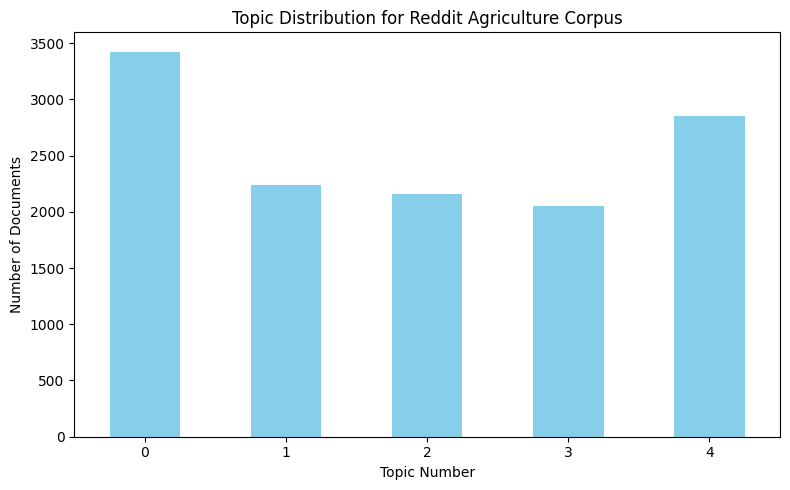

In [ ]:
import matplotlib.pyplot as plt

# Count how many posts fall under each topic
reddit_topic_counts = reddit_corpus["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))
reddit_topic_counts.plot(kind="bar", color="skyblue")
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Topic Distribution for Reddit Agriculture Corpus")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../IEEE/figures/reddit_topic_distribution.png", dpi=300)
plt.show()


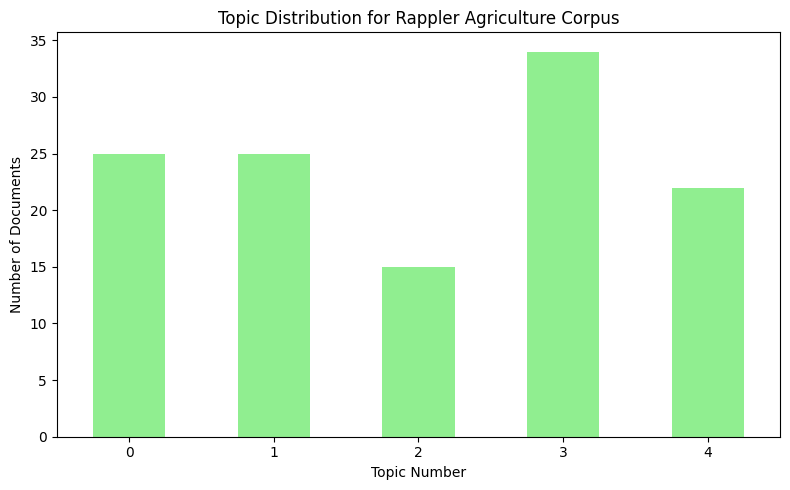

In [ ]:
rappler_topic_counts = rappler_corpus["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))
rappler_topic_counts.plot(kind="bar", color="lightgreen")
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Topic Distribution for Rappler Agriculture Corpus")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../IEEE/figures/rappler_topic_distribution.png", dpi=300)
plt.show()


## **Sentiment Analysis**

I want to approach this through BERT. The `multilingual-sentiment-analysis` model by `tabularisai` seems to be best fit as my dataset contains tagalog and english contents. Although it shows more english-comments/posts, it is necessary to try to take into account the tagalog content.


---
**Setup**

In [ ]:
!pip install transformers



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 3070


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("tabularisai/multilingual-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("tabularisai/multilingual-sentiment-analysis")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


---
**Run the code**

In [ ]:
import numpy as np
import pandas as pd

id2label = model.config.id2label

def get_sentiment(text):
    if not isinstance(text, str):
        text = str(text)

    # Tokenize and move input tensors to GPU
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        scores = outputs.logits[0]
        label_id = int(torch.argmax(scores))
        confidence = float(torch.softmax(scores, dim=0)[label_id])

    return id2label[label_id], confidence



In [ ]:
rappler_corpus = pd.read_csv("../data/News/rappler_with_topics.csv")
reddit_corpus = pd.read_csv("../data/Reddit/reddit_with_topics.csv")


In [ ]:
reddit_corpus["sentiment_label"], reddit_corpus["sentiment_score"] = zip(
    *reddit_corpus["post_full"].astype(str).apply(get_sentiment)
)

In [ ]:
rappler_corpus["sentiment_label"], rappler_corpus["sentiment_score"] = zip(
    *rappler_corpus["cleaned_text"].astype(str).apply(get_sentiment)
)

---
**Sentiment Results**

In [ ]:
reddit_corpus["sentiment_label"].value_counts()


sentiment_label
Neutral          8368
Negative         2802
Very Negative    1098
Positive          350
Very Positive     112
Name: count, dtype: int64

In [ ]:
rappler_corpus["sentiment_label"].value_counts()


sentiment_label
Neutral          113
Negative           6
Very Positive      2
Name: count, dtype: int64

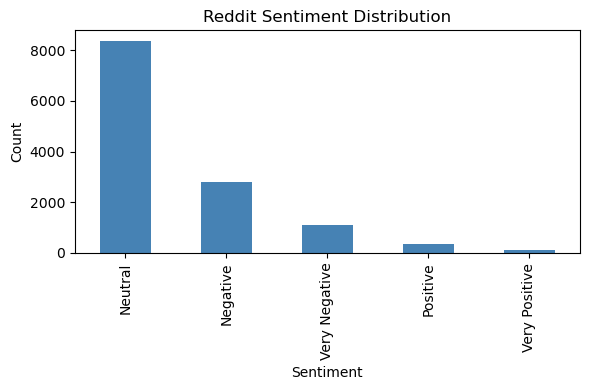

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
reddit_corpus["sentiment_label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Reddit Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../IEEE/figures/reddit_sentiment_distribution.png", dpi=300)
plt.show()


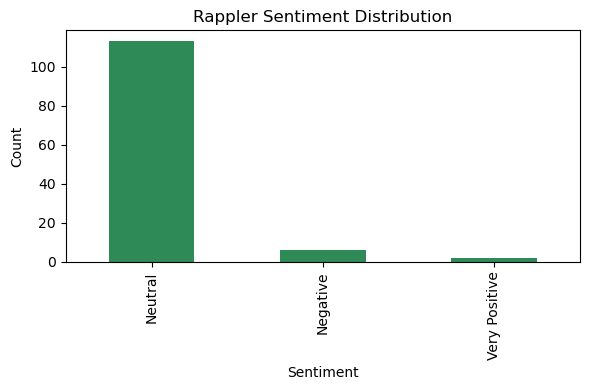

In [ ]:
plt.figure(figsize=(6,4))
rappler_corpus["sentiment_label"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Rappler Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../IEEE/figures/rappler_sentiment_distribution.png", dpi=300)
plt.show()


---
**Topic and Sentiment Overlaps**

In [ ]:
reddit_cross = pd.crosstab(
    reddit_corpus["dominant_topic"],
    reddit_corpus["sentiment_label"],
    normalize="index"   # percent per topic
)

reddit_cross


sentiment_label,Negative,Neutral,Positive,Very Negative,Very Positive
dominant_topic,,,,,
0,0.251095,0.660730,0.011971,0.075912,0.000292
1,0.402586,0.557735,0.000446,0.039233,0.000000
2,0.150463,0.720833,0.117130,0.010185,0.001389
3,0.055556,0.791910,0.025828,0.074561,0.052144
4,0.210526,0.586667,0.000702,0.201754,0.000351


In [ ]:
rappler_cross = pd.crosstab(
    rappler_corpus["dominant_topic"],
    rappler_corpus["sentiment_label"],
    normalize="index"
)

rappler_cross


sentiment_label,Negative,Neutral,Very Positive
dominant_topic,,,
0,0.000000,0.960000,0.040000
1,0.040000,0.960000,0.000000
2,0.066667,0.866667,0.066667
3,0.029412,0.970588,0.000000
4,0.136364,0.863636,0.000000


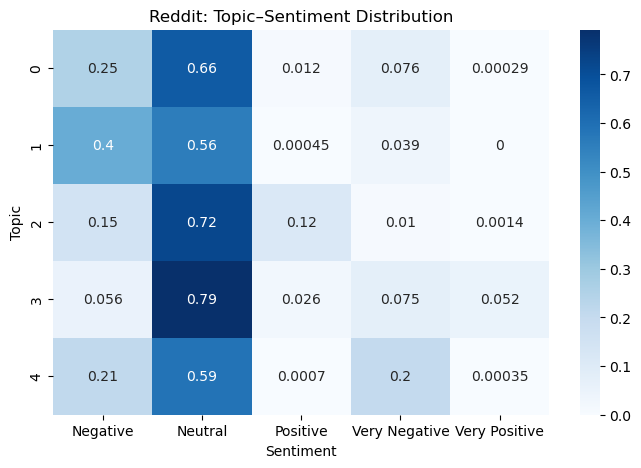

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(reddit_cross, annot=True, cmap="Blues")
plt.title("Reddit: Topic–Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.show()


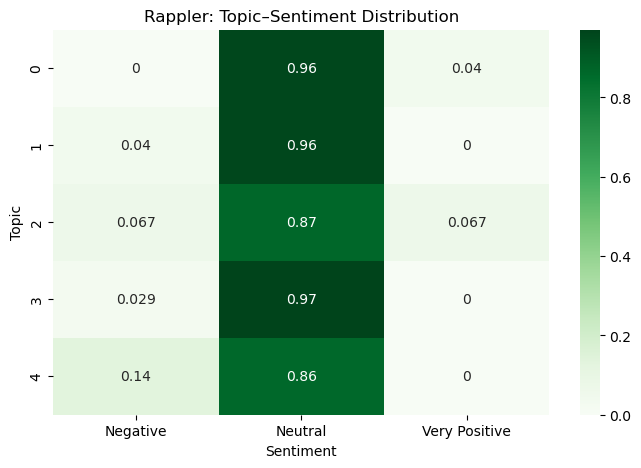

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(rappler_cross, annot=True, cmap="Greens")
plt.title("Rappler: Topic–Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.show()
